# MLDoctor - Case2
For an automated retail kiosk that recommends a new look based on a user’s current appearance, the development team developed a classifier to detect whether an individual is wearing eyeglasses, enabling the system to suggest suitable frame styles as part of the recommendation. During internal “Lab Phase” testing, the model achieved near-perfect accuracy on the company’s validation set. Engineers also observed that its performance remained stable across different lighting conditions and head poses. However, within weeks of deployment, the results from the kiosks were puzzling. While the model worked reliably for some users, its accuracy dropped significantly for others. Even more confusingly, these errors occurred in clear, well-lit images similar to those used during internal testing. Please elaborate on the identified problem, explain how it was identified, and provide a recommended solution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns

#import torch which has many of the functions to build deep learning models and to train them
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

#import torchvision, which was lots of functions for loading and working with image data
import torchvision
import torchvision.transforms as transforms

#this is a nice progress bar representation that will be good to measure progress during training
import tqdm
import copy
import random

# fix seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

# setup device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu') #this line checks if we have a GPU available
print(f"Using device: {device}")

Using device: cuda:0


## Data

In [2]:
# Load the full training dataset first (without transforms for now)
test_internal_dataset = torchvision.datasets.ImageFolder('Case2Dataset/test_internal')
print(f'Validation dataset size: {len(test_internal_dataset)}')
test_external_dataset = torchvision.datasets.ImageFolder('Case2Dataset/test_external')
print(f'Test external dataset size: {len(test_external_dataset)}')

# Imnagenet preprocessing
imagenet_means = (0.485, 0.456, 0.406)
imagenet_stds = (0.229, 0.224, 0.225)

# preprocessing transform
transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Resize((224, 224)), 
    transforms.Normalize(imagenet_means, imagenet_stds)])


# Apply transforms to the datasets
test_internal_dataset.transform = transform
test_external_dataset.transform = transform

# create dataloaders for train, val, test datasets
batch_size = 16
test_internal_loader = torch.utils.data.DataLoader(test_internal_dataset, batch_size=batch_size, shuffle=False, num_workers = 1)
test_external_loader = torch.utils.data.DataLoader(test_external_dataset, batch_size=batch_size, shuffle=False, num_workers = 1)

Validation dataset size: 300
Test external dataset size: 300


## Developed Model

In [5]:
def setup_model(model, num_classes, freeze_backbone = False):
    
    #### Adapt the architecture for the new number of classes.
    in_features = model.fc.in_features
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    #### If necessary, freeze any weights.
    if freeze_backbone: 
        for param in model.parameters():
            param.requires_grad = False
        
        # Unfreeze the parameters of the last fully connected layer
        for param in model.fc.parameters():
            param.requires_grad = True

    return model

# setup the model
backbone = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
resnet_frozen = setup_model(backbone, 2, False)

# Load the developed model
resnet_frozen.load_state_dict(torch.load("resnet_frozen_best_case2.pth"))
resnet_frozen.eval()
resnet_frozen = resnet_frozen.to(device)
print(resnet_frozen)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

## Evaluation

In [6]:
# Load the best model
resnet_frozen.eval()

# Collect predictions and ground truth labels
all_predictions = {'internal': [], 'external': []}
all_labels = {'internal': [], 'external': []}

# compute predictions
with torch.no_grad():
    for split, dataloader in zip(['internal', 'external'], [test_internal_loader, test_external_loader]):
        for data in tqdm.tqdm(dataloader, desc=f'Evaluating on {split} set'):
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = resnet_frozen(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_predictions[split].append(probs.cpu().numpy())
            all_labels[split].append(labels.cpu().numpy())
print("Evaluation complete.")

for split in ['internal', 'external']:
    all_predictions[split] = np.concatenate(all_predictions[split], axis=0)
    all_labels[split] = np.concatenate(all_labels[split], axis=0)
    predicted_classes = np.argmax(all_predictions[split], axis=1)
    accuracy = (predicted_classes == all_labels[split]).mean()
    print(f"{split} set - Accuracy: {accuracy:.3f}")

Evaluating on external set: 100%|██████████| 19/19 [00:01<00:00, 13.43it/s]

Evaluation complete.
internal set - Accuracy: 0.987
external set - Accuracy: 0.710


Class mapping: {'negative': 0, 'positive': 1}


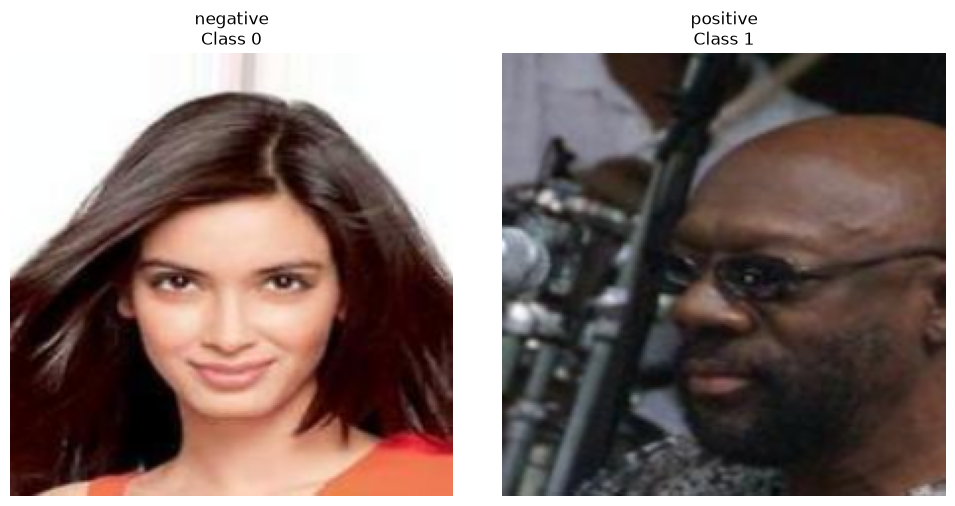

In [7]:
# Check class names and corresponding indices
print("Class mapping:",test_internal_dataset.class_to_idx)

# Display one sample image from each class
fig,axes=plt.subplots(1,len(test_internal_dataset.classes),figsize=(10,5))

for class_idx,class_name in enumerate(test_internal_dataset.classes):

    # Find the first sample belonging to this class
    sample_idx=test_internal_dataset.targets.index(class_idx)
    image,label=test_internal_dataset[sample_idx]

    # Reverse ImageNet normalization for visualization
    image=image.cpu().numpy().transpose(1,2,0)
    image=image*np.array(imagenet_stds)+np.array(imagenet_means)
    image=np.clip(image,0,1)

    # Display the sample image
    axes[class_idx].imshow(image)
    axes[class_idx].set_title(f"{class_name}\nClass {class_idx}")
    axes[class_idx].axis("off")

plt.tight_layout()
plt.show()


===== INTERNAL SET =====
Accuracy : 0.987
Precision: 1.000
Recall   : 0.973
F1-score : 0.986


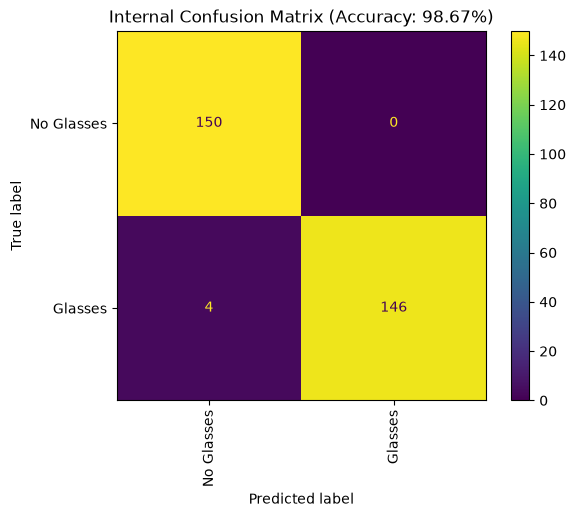


===== EXTERNAL SET =====
Accuracy : 0.710
Precision: 0.756
Recall   : 0.620
F1-score : 0.681


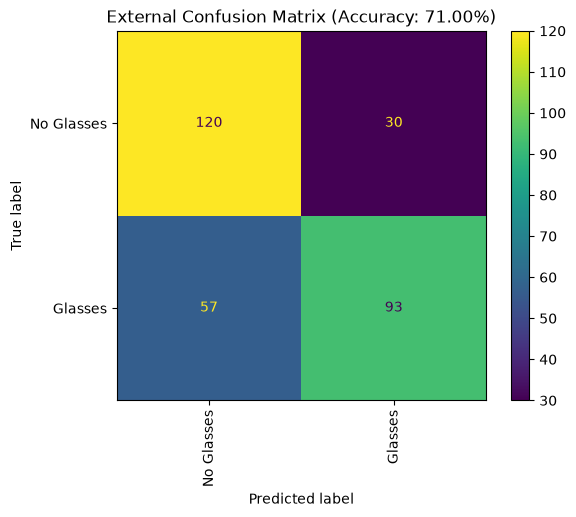

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

# Compute TP, FP, TN, FN for binary classification
def confusion_matrix_counts(labels, probs, threshold=0.5):
    
    labels = labels.astype(bool)
    probs = probs.astype(float)

    # Convert probabilities to binary predictions
    preds = probs >= threshold

    tp = np.sum(preds & labels)
    fp = np.sum(preds & ~labels)
    tn = np.sum(~preds & ~labels)
    fn = np.sum(~preds & labels)

    return tp, fp, tn, fn


# Compute precision, recall and F1-score
def compute_metrics(labels, probs, threshold=0.5):
    
    tp, fp, tn, fn = confusion_matrix_counts(
        labels,
        probs,
        threshold=threshold
    )

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    return precision, recall, f1


# Evaluate the model on the internal and external test sets
threshold = 0.5

for split in ['internal', 'external']:

    # Ground-truth labels: 0 = No Glasses, 1 = Glasses
    labels = all_labels[split]

    # Predicted probability for the positive class (Glasses)
    probs_glasses = all_predictions[split][:, 1]

    # Convert probabilities to predicted classes
    preds = probs_glasses >= threshold

    # Compute evaluation metrics
    accuracy = (preds == labels.astype(bool)).mean()
    precision, recall, f1 = compute_metrics(
        labels,
        probs_glasses,
        threshold=threshold
    )

    # Print results
    print(f"\n===== {split.upper()} SET =====")
    print(f"Accuracy : {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall   : {recall:.3f}")
    print(f"F1-score : {f1:.3f}")

    # Plot confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        labels,
        preds,
        display_labels=['No Glasses', 'Glasses'],
        xticks_rotation='vertical'
    )

    plt.title(
        f'{split.capitalize()} Confusion Matrix '
        f'(Accuracy: {accuracy * 100:.2f}%)'
    )

    plt.show()

Accuracy decreased substantially from 98.7% on the internal test set to 71.0% on the external test set. False positives increased from 0 to 30, while false negatives increased from 4 to 57.

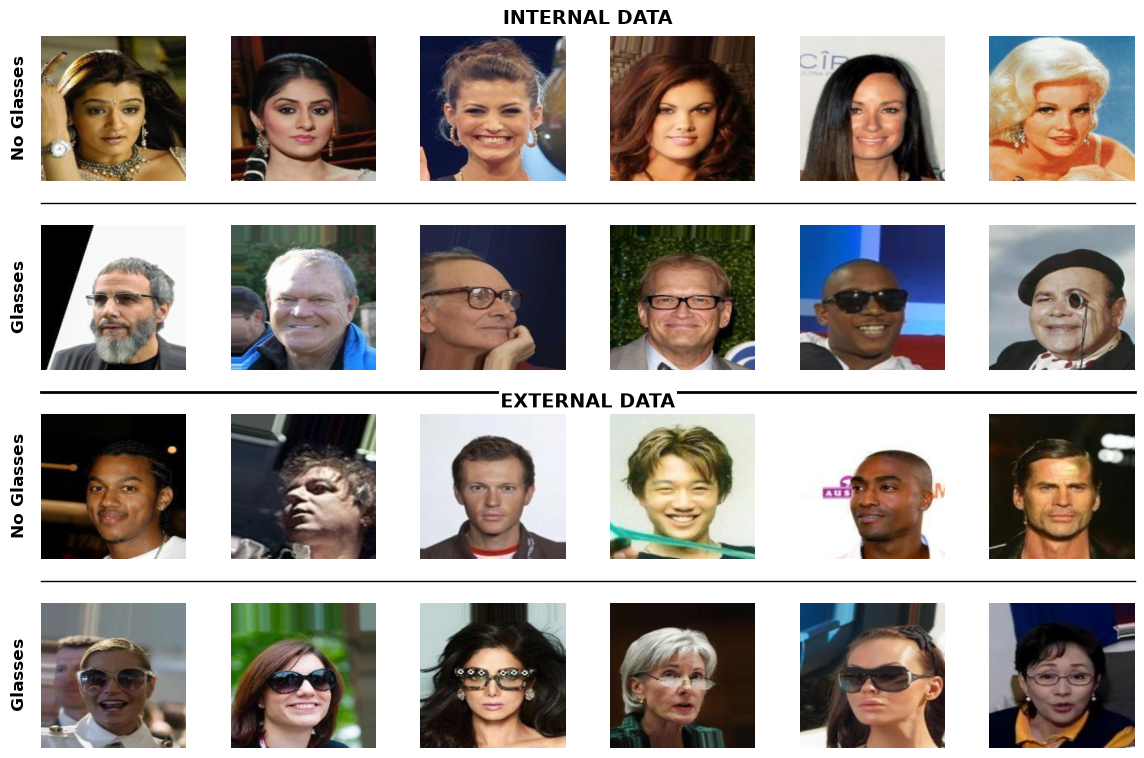

In [18]:
# Identify samples by actual class
internal_labels=all_labels['internal']
external_labels=all_labels['external']

internal_no_glasses=np.where(internal_labels==0)[0]
internal_glasses=np.where(internal_labels==1)[0]
external_no_glasses=np.where(external_labels==0)[0]
external_glasses=np.where(external_labels==1)[0]

# Select 6 samples from each group
np.random.seed(0)
selected_internal_no_glasses=np.random.choice(internal_no_glasses,6,replace=False)
selected_internal_glasses=np.random.choice(internal_glasses,6,replace=False)
selected_external_no_glasses=np.random.choice(external_no_glasses,6,replace=False)
selected_external_glasses=np.random.choice(external_glasses,6,replace=False)

# Denormalize images for visualization
def denormalize_image(image):
    image=image.numpy().transpose(1,2,0)
    image=image*np.array(imagenet_stds)+np.array(imagenet_means)
    return np.clip(image,0,1)

# Define groups
groups=[
    (test_internal_dataset,selected_internal_no_glasses,'No Glasses'),
    (test_internal_dataset,selected_internal_glasses,'Glasses'),
    (test_external_dataset,selected_external_no_glasses,'No Glasses'),
    (test_external_dataset,selected_external_glasses,'Glasses')
]

# Create figure
fig,axes=plt.subplots(4,6,figsize=(13,8))

for row,(dataset,indices,class_name) in enumerate(groups):
    for col,idx in enumerate(indices):
        image,label=dataset[idx]
        axes[row,col].imshow(denormalize_image(image))

        # Hide ticks but keep y-axis label visible
        axes[row,col].set_xticks([])
        axes[row,col].set_yticks([])
        
        # Hide plot borders
        for spine in axes[row,col].spines.values():
            spine.set_visible(False)

    # Show actual class on y-axis
    axes[row,0].set_ylabel(
        class_name,
        fontsize=12,
        fontweight='bold',
        labelpad=10
    )

# Reduce empty space
plt.subplots_adjust(left=0.11,right=0.98,top=0.93,bottom=0.04,hspace=0.30,wspace=0.04)
fig.canvas.draw()

# Plot boundaries
x_left=axes[0,0].get_position().x0
x_right=axes[0,5].get_position().x1

# INTERNAL DATA title
y_internal_title=axes[0,0].get_position().y1+0.015
fig.text(
    (x_left+x_right)/2,
    y_internal_title,
    'INTERNAL DATA',
    ha='center',
    fontsize=14,
    fontweight='bold'
)

# Divider between No Glasses and Glasses
y_internal=(axes[0,0].get_position().y0+axes[1,0].get_position().y1)/2
fig.add_artist(plt.Line2D(
    [x_left,x_right],
    [y_internal,y_internal],
    transform=fig.transFigure,
    color='black',
    linewidth=1
))

# Divider between Internal and External
y_dataset=(axes[1,0].get_position().y0+axes[2,0].get_position().y1)/2
fig.add_artist(plt.Line2D(
    [x_left,x_right],
    [y_dataset,y_dataset],
    transform=fig.transFigure,
    color='black',
    linewidth=2
))

# EXTERNAL DATA title
y_external_title=axes[2,0].get_position().y1+0.008
fig.text(
    (x_left+x_right)/2,
    y_external_title,
    'EXTERNAL DATA',
    ha='center',
    fontsize=14,
    fontweight='bold',
    bbox=dict(facecolor='white',edgecolor='none',pad=1)
)

# Divider between No Glasses and Glasses
y_external=(axes[2,0].get_position().y0+axes[3,0].get_position().y1)/2
fig.add_artist(plt.Line2D(
    [x_left,x_right],
    [y_external,y_external],
    transform=fig.transFigure,
    color='black',
    linewidth=1
))

plt.show()

Visual inspection revealed a strong spurious correlation between the eyeglasses label and gender-associated appearance in the sampled images. In the internal data, No Glasses samples were female-presenting while Glasses samples were male-presenting. In the external data, this relationship was reversed, with No Glasses samples being male-presenting and Glasses samples being female-presenting. This distribution shift suggests that the model may have learned gender-associated facial features as a shortcut for eyeglasses classification rather than relying exclusively on the presence of eyeglasses.

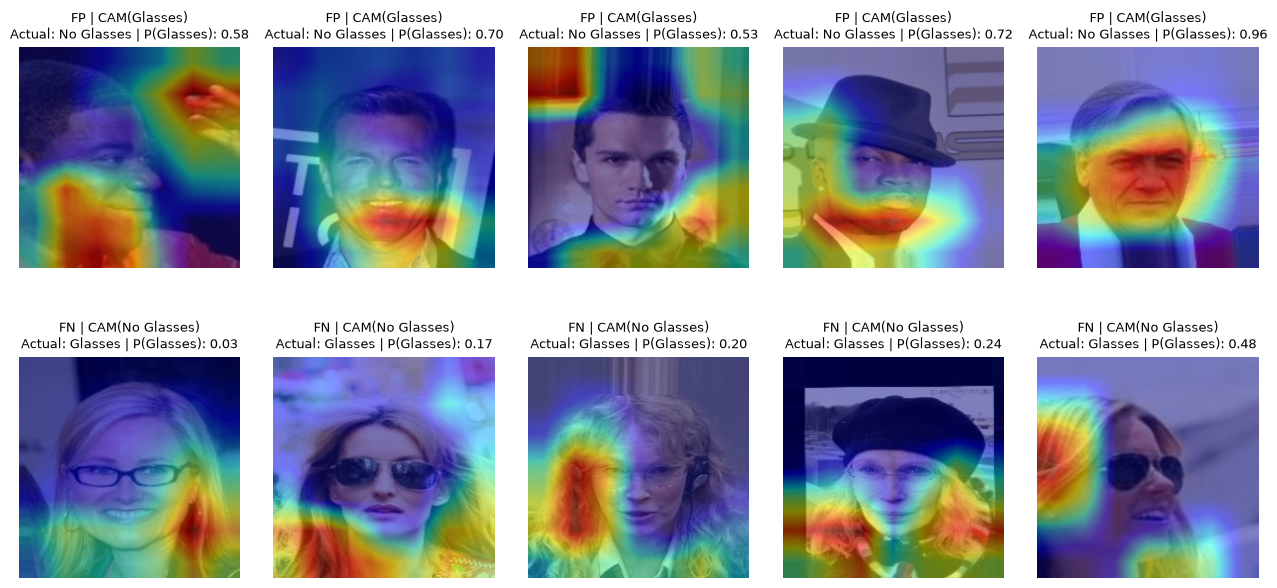

In [27]:
# Get external labels and predicted probabilities
labels=all_labels['external']
probs_glasses=all_predictions['external'][:,1]
preds=probs_glasses>=0.5

# Identify FP and FN samples
fp_indices=np.where((labels==0)&(preds==1))[0]
fn_indices=np.where((labels==1)&(preds==0))[0]

# Select five samples from each error group
np.random.seed(10)
selected_fp=np.random.choice(fp_indices,5,replace=False)
selected_fn=np.random.choice(fn_indices,5,replace=False)

# Store the output of the final convolutional layer
activation={}

def get_activation(name):
    def hook(model,input,output):
        activation[name]=output.detach()
    return hook

# Capture feature maps from the final ResNet18 convolutional block
hook_handle=resnet_frozen.layer4[1].conv2.register_forward_hook(
    get_activation('resnet.layer4.1.conv2')
)

# Arrange FP and FN samples
cam_groups=[
    ('FP',selected_fp),
    ('FN',selected_fn)
]

resnet_frozen.eval()
fig,axes=plt.subplots(2,5,figsize=(16,7))

with torch.no_grad():
    for row,(result,indices) in enumerate(cam_groups):
        for col,idx in enumerate(indices):
            x,y=test_external_dataset[idx]
            x=x.to(device)

            # Run inference
            output=resnet_frozen(x.unsqueeze(0))
            pred=torch.argmax(output,dim=1).item()
            prob_glasses=torch.softmax(output,dim=1)[0,1].item()

            # Get the convolutional feature maps
            conv_feature_map=activation['resnet.layer4.1.conv2'][0].detach()

            # Use classifier weights for the predicted class
            fc_weights=resnet_frozen.state_dict()['fc.weight'][pred].detach()

            # Compute the class activation map
            cam=torch.sum(fc_weights[:,None,None]*conv_feature_map,dim=0)
            cam=torch.clamp(cam,min=0)

            # Normalize CAM values to [0,1]
            if torch.max(cam)>0:
                cam=cam/torch.max(cam)

            # Resize CAM to the input image size
            cam=F.interpolate(
                cam.unsqueeze(0).unsqueeze(0),
                size=(x.shape[1],x.shape[2]),
                mode='bilinear',
                align_corners=False
            ).squeeze().cpu().numpy()

            # Reverse ImageNet normalization for visualization
            x_display=x.detach().cpu().numpy().transpose(1,2,0)*np.array(imagenet_stds)+np.array(imagenet_means)
            x_display=np.clip(x_display,0,1)

            actual='Glasses' if y==1 else 'No Glasses'
            predicted='Glasses' if pred==1 else 'No Glasses'

            # Plot CAM
            axes[row,col].imshow(x_display)
            axes[row,col].imshow(cam,alpha=0.5,cmap='jet')
            axes[row,col].set_title(
                f'{result} | CAM({predicted})\n'
                f'Actual: {actual} | P(Glasses): {prob_glasses:.2f}',
                fontsize=9
            )
            axes[row,col].axis('off')

# Label error groups
axes[0,0].set_ylabel('FP\nNo Glasses → Glasses',fontsize=11,labelpad=10)
axes[1,0].set_ylabel('FN\nGlasses → No Glasses',fontsize=11,labelpad=10)

plt.subplots_adjust(hspace=0.35,wspace=0.15)
plt.show()

# Remove the forward hook
hook_handle.remove()

CAM analysis further supports the presence of shortcut learning. In many misclassified samples, the strongest activations were not concentrated on the eyeglass region. FN samples frequently showed strong activation around the hair, while FP samples exhibited less consistent activation across the lower face, facial contours, and surrounding regions. This further supports the hypothesis that the model learned to associate female-presenting features with No Glasses and male-presenting features with Glasses from the internal data, leading to gender-related confusion when applied to the external data.

> **Diagnosis:** The model appears to have associated male-presenting facial appearance with the presence of eyeglasses and female-presenting appearance with the absence of eyeglasses in the internal dataset. This association became unreliable on the external dataset, where the gender-associated patterns were reversed, leading to increased confusion between the Glasses and No Glasses classes.

> **Evidence:** Accuracy decreased substantially from 98.7% on the internal test set to 71.0% on the external test set. False positives increased from 0 to 30 and false negatives increased from 4 to 57. Visual inspection revealed a strong difference in the relationship between gender-associated appearance and the eyeglasses label across the two datasets. In the sampled internal data, No Glasses images were female-presenting, while Glasses images were male-presenting. In contrast, this relationship was reversed in the sampled external data, where No Glasses images were male-presenting and Glasses images were female-presenting. CAM analysis provided further evidence that the model was not consistently focusing on the eyeglass region. In many misclassified samples, the strongest activations were not concentrated on the eyeglass region. FN samples frequently showed strong activation around the hair, while FP samples exhibited less consistent activation across the lower face, facial contours, and surrounding regions. Together, these findings suggest that the model relied on gender-associated appearance as a predictive cue for eyeglasses, which became unreliable when the relationship changed in the external data.

> **Recommendation:** The training and validation datasets should include diverse gender-associated appearances across both the Glasses and No Glasses classes, ensuring that male- and female-presenting individuals are sufficiently represented in both classes. Model performance should also be evaluated separately across relevant gender-associated subgroups to identify potential performance disparities. In addition, saliency or feature-attribution checks should be incorporated into model evaluation to verify that predictions are primarily based on the eyeglass region rather than unrelated facial or appearance-related features.